In [1]:
import pandas as pd
import requests

In [4]:
df=pd.read_csv('/content/telecom_x_cleaned_data.csv')
display(df.head())
df.info()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Churn_Numeric,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0.0,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0.0,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1.0,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1.0,2.80


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [8]:
#notemos que estas columnas no suman valor predictivo
colum_eliminar=['customerID','Churn','Cuentas_Diarias']
df_limpio=df.drop(columns=colum_eliminar)
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7267 non-null   object 
 1   SeniorCitizen     7267 non-null   int64  
 2   Partner           7267 non-null   object 
 3   Dependents        7267 non-null   object 
 4   tenure            7267 non-null   int64  
 5   PhoneService      7267 non-null   object 
 6   MultipleLines     7267 non-null   object 
 7   InternetService   7267 non-null   object 
 8   OnlineSecurity    7267 non-null   object 
 9   OnlineBackup      7267 non-null   object 
 10  DeviceProtection  7267 non-null   object 
 11  TechSupport       7267 non-null   object 
 12  StreamingTV       7267 non-null   object 
 13  StreamingMovies   7267 non-null   object 
 14  Contract          7267 non-null   object 
 15  PaperlessBilling  7267 non-null   object 
 16  PaymentMethod     7267 non-null   object 


In [10]:
columnas_categoricas=df_limpio.select_dtypes(include=['object']).columns.tolist()
columnas_categoricas

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [12]:
df_trabajo=pd.get_dummies(df_limpio,columns=columnas_categoricas,dtype=int)
print(f"Forma del dataset original: {df_limpio.shape}")
print(f"Forma después del One-Hot Encoding: {df_trabajo.shape}")
print("\nPrimeras 5 filas con variables numéricas:")
print(df_trabajo.head())


Forma del dataset original: (7267, 20)
Forma después del One-Hot Encoding: (7267, 46)

Primeras 5 filas con variables numéricas:
   SeniorCitizen  tenure  Charges.Monthly  Charges.Total  Churn_Numeric  \
0              0       9             65.6         593.30            0.0   
1              0       9             59.9         542.40            0.0   
2              0       4             73.9         280.85            1.0   
3              1      13             98.0        1237.85            1.0   
4              1       3             83.9         267.40            1.0   

   gender_Female  gender_Male  Partner_No  Partner_Yes  Dependents_No  ...  \
0              1            0           0            1              0  ...   
1              0            1           1            0              1  ...   
2              0            1           1            0              1  ...   
3              0            1           0            1              1  ...   
4              1            0 

In [16]:
churn_counts=df_trabajo['Churn_Numeric'].value_counts()
churn_proportions=df_trabajo['Churn_Numeric'].value_counts(normalize=True)*100
print(f'Numero de clientes por clase de Churn: {churn_counts} ')

print(f'\nNumero de clientes por clase de Churn (%): {churn_proportions} ')

Numero de clientes por clase de Churn: Churn_Numeric
0.0    5174
1.0    1869
Name: count, dtype: int64 

Numero de clientes por clase de Churn (%): Churn_Numeric
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64 


### Preparando los datos para balanceo (SMOTE)

Antes de aplicar técnicas de balanceo, es crucial separar las características (X) de la variable objetivo (y) y dividir el dataset en conjuntos de entrenamiento y prueba.

In [28]:
from sklearn.model_selection import train_test_split
X=df_trabajo.drop('Churn_Numeric',axis=1)
y=df_trabajo['Churn_Numeric']

# Imputar los valores NaN en la columna 'Charges.Total' ANTES de dividir los datos
X['Charges.Total'] = X['Charges.Total'].fillna(X['Charges.Total'].mean())

# Eliminar filas con valores NaN en el target 'Churn_Numeric'
nan_indices=y[y.isna()].index
X_cleaned=X.drop(nan_indices)
y_cleaned=y.drop(nan_indices)
#Divimos el conjunto de datos en entrenamiento y prueba
X_train,X_test,y_train,y_test=train_test_split(X_cleaned,y_cleaned,test_size=0.3,random_state=42,stratify=y_cleaned)
print(f'Forma de X_train antes de SMOTE:{X_train.shape}')
print(f'Forma de y_train antes de SMOTE:{y_train.shape}')
print(f'Distribucion de y_train antes de SMOTE:{y_train.value_counts(normalize=True)}')

Forma de X_train antes de SMOTE:(4930, 45)
Forma de y_train antes de SMOTE:(4930,)
Distribucion de y_train antes de SMOTE:Churn_Numeric
0.0    0.734686
1.0    0.265314
Name: proportion, dtype: float64


### Aplicando SMOTE para balancear la clase minoritaria

SMOTE (Synthetic Minority Over-sampling Technique) es una técnica popular para abordar el desbalance de clases. Funciona creando nuevas instancias sintéticas de la clase minoritaria a partir de las muestras existentes, en lugar de simplemente duplicarlas. Esto ayuda a evitar el sobreajuste que podría ocurrir con el oversampling simple.

In [29]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote= smote.fit_resample(X_train,y_train)

print(f'Forma de X_train despues de SMOTE:{X_train_smote.shape}')
print(f'Forma de y_train despues de SMOTE:{y_train_smote.shape}')
print(f'Distribucion de y_train despues de SMOTE:{y_train_smote.value_counts(normalize=True)}')

Forma de X_train despues de SMOTE:(7244, 45)
Forma de y_train despues de SMOTE:(7244,)
Distribucion de y_train despues de SMOTE:Churn_Numeric
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


##Visualizacion de la matriz de correlación
Para identificar las relaciones entre las variables numéricas y, en particular, su correlación con la variable `Churn_Numeric`, generaremos un mapa de calor de la matriz de correlación.

Correlacion de las variables con respecto a Churn_Numeric:Churn_Numeric                              1.000000
Contract_Month-to-month                    0.405103
OnlineSecurity_No                          0.342637
TechSupport_No                             0.337281
InternetService_Fiber optic                0.308020
PaymentMethod_Electronic check             0.301919
OnlineBackup_No                            0.268005
DeviceProtection_No                        0.252481
Charges.Monthly                            0.193356
PaperlessBilling_Yes                       0.191825
Dependents_No                              0.164221
SeniorCitizen                              0.150889
Partner_No                                 0.150448
StreamingMovies_No                         0.130845
StreamingTV_No                             0.128916
StreamingTV_Yes                            0.063228
StreamingMovies_Yes                        0.061382
MultipleLines_Yes                          0.040102
PhoneS

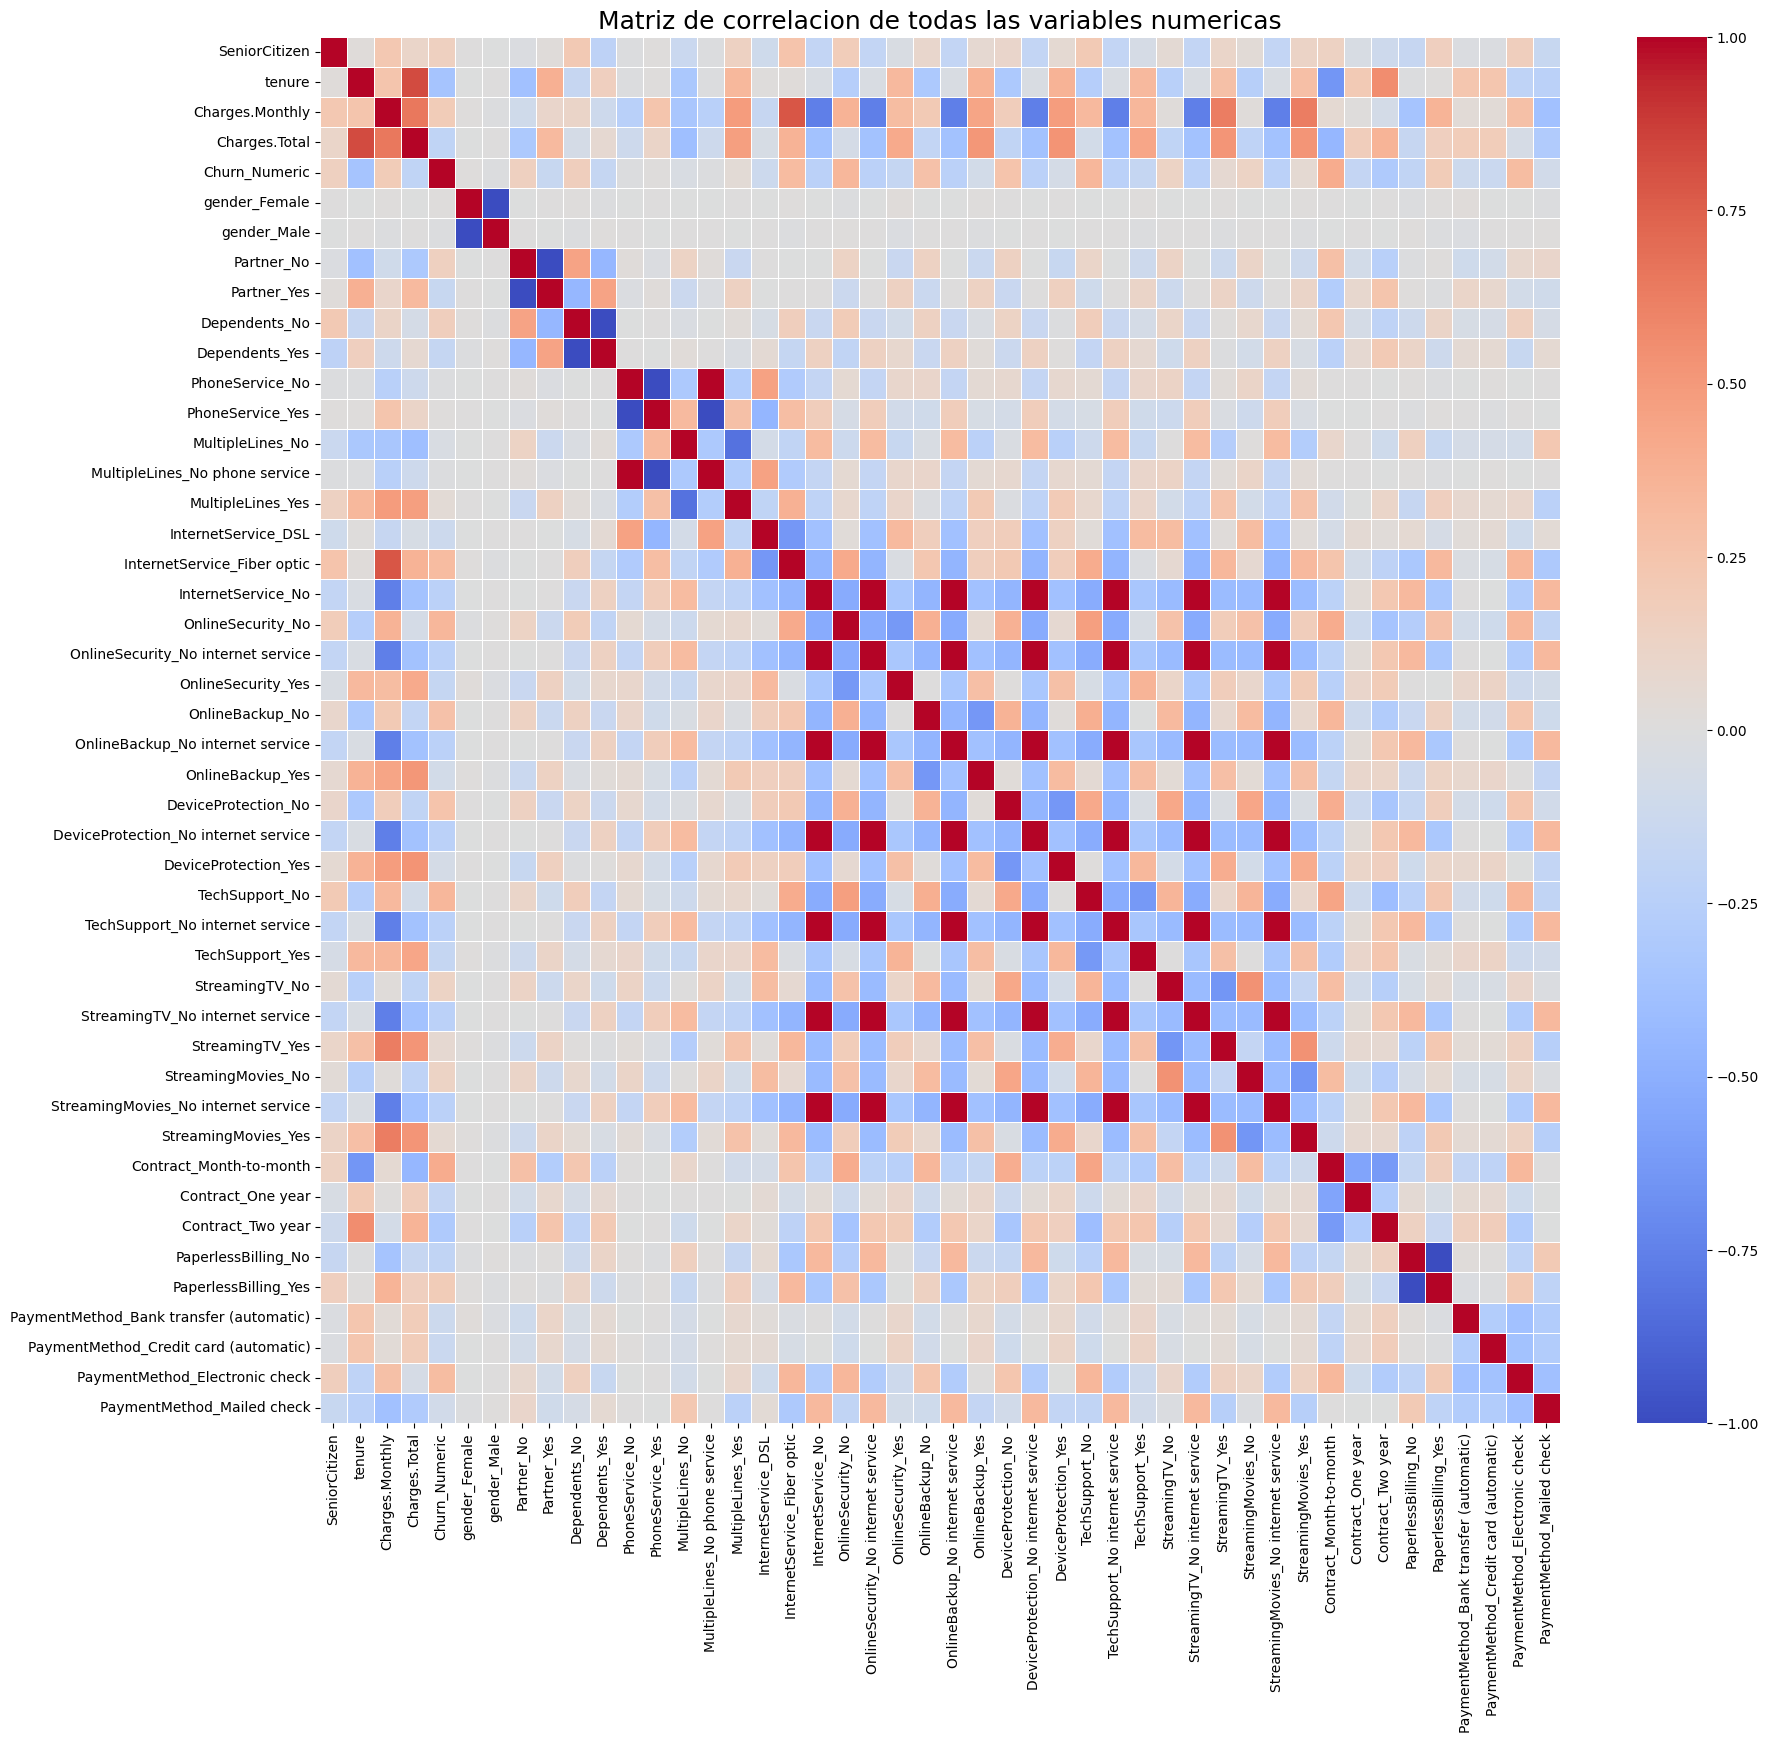

/tmp/ipykernel_1438/2192067929.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_correlation.index, y=churn_correlation.values, palette='viridis')


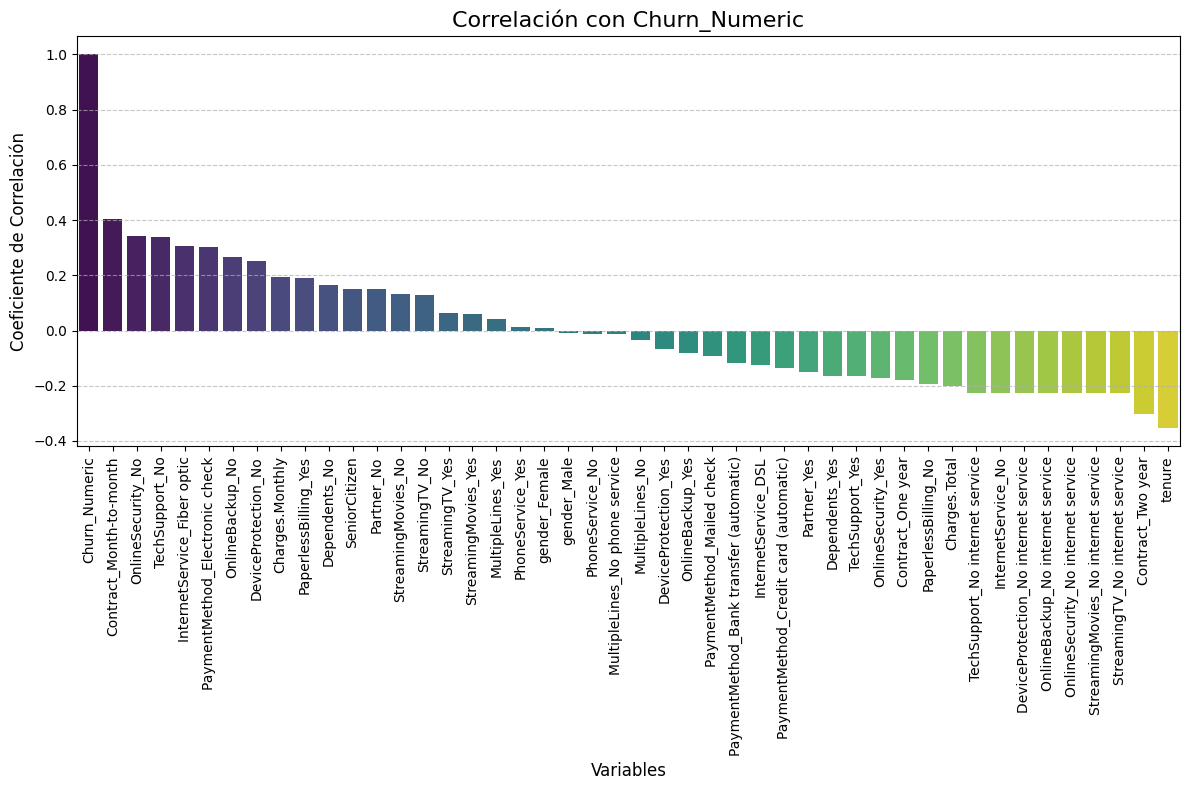

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix=df_trabajo.corr()
#como queremos ver con respecto a CHURN
churn_correlation=correlation_matrix['Churn_Numeric'].sort_values(ascending=False)
print(f'Correlacion de las variables con respecto a Churn_Numeric:{churn_correlation}')
#grafico de matriz
plt.figure(figsize=(20,18))
sns.heatmap(correlation_matrix,annot=False,cmap='coolwarm',fmt='.2f',linewidths=.5)
plt.title('Matriz de correlacion de todas las variables numericas',fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

plt.figure(figsize=(12, 8))
sns.barplot(x=churn_correlation.index, y=churn_correlation.values, palette='viridis')
plt.title('Correlación con Churn_Numeric', fontsize=16)
plt.xlabel('Variables', fontsize=12)
plt.ylabel('Coeficiente de Correlación', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análisis Dirigido

Vamos a visualizar la relación entre 'Tiempo de contrato' (`tenure`) y 'Gasto total' (`Charges.Total`) con la variable objetivo `Churn_Numeric` utilizando boxplots y scatter plots.

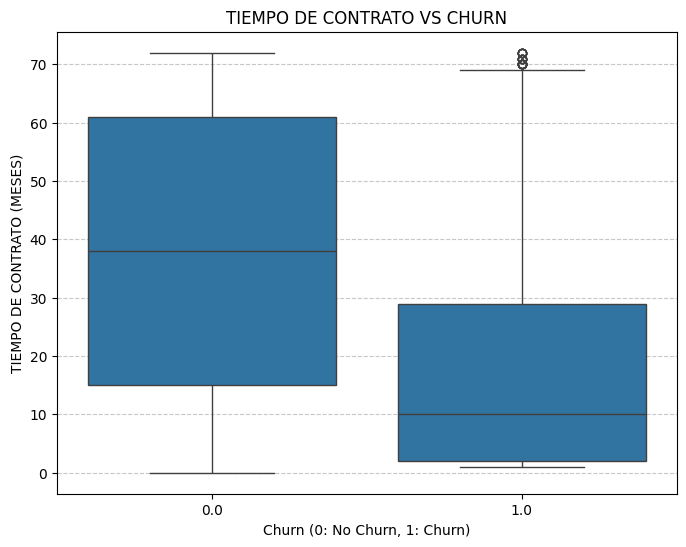

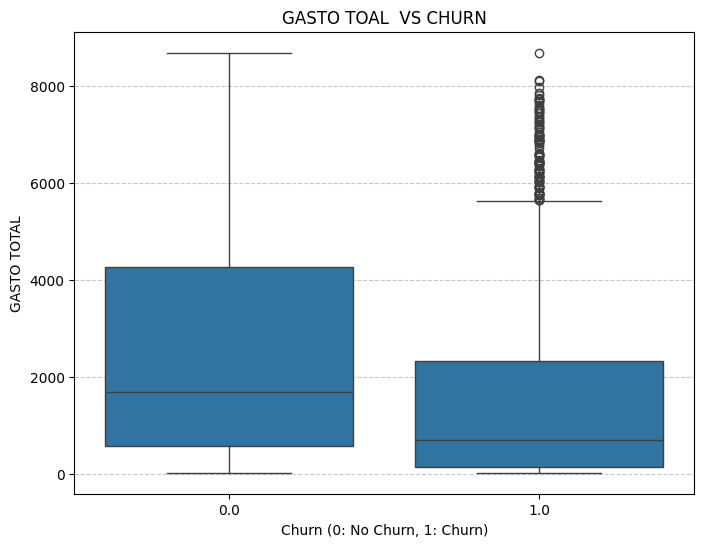

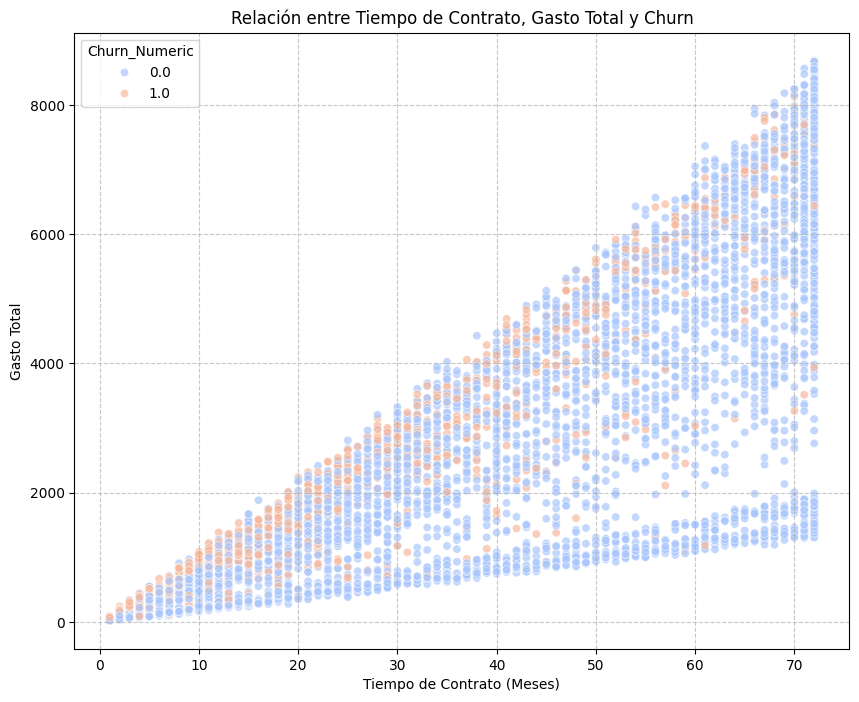

In [37]:
#Boxplot para tenure y Churn_numeric
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn_Numeric',y='tenure',data=df_trabajo)
plt.title('TIEMPO DE CONTRATO VS CHURN')
plt.xlabel('Churn (0: No Churn, 1: Churn)')
plt.ylabel('TIEMPO DE CONTRATO (MESES)')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

# Boxplot para 'Charges.Total' vs 'Churn_Numeric'
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn_Numeric',y='Charges.Total',data=df_trabajo)
plt.title('GASTO TOAL  VS CHURN')
plt.xlabel('Churn (0: No Churn, 1: Churn)')
plt.ylabel('GASTO TOTAL')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

# Scatter plot para 'tenure' y 'Charges.Total' coloreado por 'Churn_Numeric'
plt.figure(figsize=(10, 8))
sns.scatterplot(x='tenure', y='Charges.Total', hue='Churn_Numeric', data=df_trabajo, palette='coolwarm', alpha=0.7)
plt.title('Relación entre Tiempo de Contrato, Gasto Total y Churn')
plt.xlabel('Tiempo de Contrato (Meses)')
plt.ylabel('Gasto Total')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 1. Normalización de Datos para Modelos Sensibles a la Escala

Para modelos como la Regresión Logística, que calculan distancias o se basan en coeficientes que pueden verse afectados por la magnitud de las variables, es fundamental escalar los datos. Utilizaremos `StandardScaler` para estandarizar las características, transformándolas para que tengan una media de 0 y una desviación estándar de 1. Esto asegura que ninguna característica domine desproporcionadamente el cálculo de la función de coste o la determinación de los límites de decisión del modelo.

In [38]:
from sklearn.preprocessing import StandardScaler

# Inicializar el StandardScaler
scaler = StandardScaler()

# Escalar los datos de entrenamiento (después de SMOTE) y de prueba
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Datos de entrenamiento escalados (primeras 5 filas):")
print(X_train_smote_scaled[:5])
print("\nDatos de prueba escalados (primeras 5 filas):")
print(X_test_scaled[:5])

Datos de entrenamiento escalados (primeras 5 filas):
[[-0.39647005 -0.56183424  0.29029965 -0.42295049 -0.87028692  1.1327016
   0.99586718 -0.77152015  0.66366062 -0.52645125 -0.2795293   0.32886713
   1.17131174 -0.2795293  -0.78800018 -0.63208886  0.97249302 -0.44157123
   0.90055538 -0.44157123 -0.50801154  1.07187557 -0.44157123 -0.60180248
  -0.91167021 -0.44157123  1.63848676  0.91370296 -0.44157123 -0.51788733
   1.2572554  -0.44157123 -0.74509992  1.27200544 -0.44157123 -0.74554807
   0.75431041 -0.41880973 -0.44491504  1.53316708 -1.24203323 -0.43552993
  -0.42923262  1.37795483 -0.46502959]
 [-0.39647005 -0.93775117  0.06506971 -0.77635871 -0.87028692  1.1327016
   0.99586718 -0.77152015  0.66366062 -0.52645125 -0.2795293   0.32886713
   1.17131174 -0.2795293  -0.78800018  1.58205605 -1.02828501 -0.44157123
   0.90055538 -0.44157123 -0.50801154  1.07187557 -0.44157123 -0.60180248
  -0.91167021 -0.44157123  1.63848676  0.91370296 -0.44157123 -0.51788733
  -0.79538334 -0.44157

### 2. Modelo 1: Regresión Logística (con datos escalados)

La Regresión Logística es un modelo lineal que estima la probabilidad de que una instancia pertenezca a una clase particular. Debido a su naturaleza, es sensible a la escala de los datos, por lo que usaremos los datos `X_train_smote_scaled` y `X_test_scaled`.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Inicializar y entrenar el modelo de Regresión Logística
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train_smote_scaled, y_train_smote)

# Realizar predicciones en el conjunto de prueba escalado
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

# Evaluar el modelo
print("\n--- Evaluación del Modelo de Regresión Logística ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log_reg))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log_reg))


--- Evaluación del Modelo de Regresión Logística ---
Accuracy: 0.7851

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.85      0.86      0.85      1552
         1.0       0.60      0.58      0.59       561

    accuracy                           0.79      2113
   macro avg       0.72      0.72      0.72      2113
weighted avg       0.78      0.79      0.78      2113


Matriz de Confusión:
[[1336  216]
 [ 238  323]]


### 3. Modelo 2: Random Forest Classifier (sin normalización)

Random Forest es un modelo de conjunto basado en árboles de decisión. Como los modelos basados en árboles no son sensibles a la escala de las características (ya que las decisiones se basan en umbrales de las características, no en su magnitud), podemos usar los datos originales no escalados (`X_train_smote` y `X_test`).

In [40]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar y entrenar el modelo Random Forest
# Usamos los datos no escalados
rf_model = RandomForestClassifier(random_state=42, n_estimators=100) # n_estimators: número de árboles
rf_model.fit(X_train_smote, y_train_smote)

# Realizar predicciones en el conjunto de prueba no escalado
y_pred_rf = rf_model.predict(X_test)

# Evaluar el modelo
print("\n--- Evaluación del Modelo Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))


--- Evaluación del Modelo Random Forest ---
Accuracy: 0.7728

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.83      0.87      0.85      1552
         1.0       0.58      0.51      0.55       561

    accuracy                           0.77      2113
   macro avg       0.71      0.69      0.70      2113
weighted avg       0.77      0.77      0.77      2113


Matriz de Confusión:
[[1345  207]
 [ 273  288]]


### Resumen de la Evaluación de Modelos

Se entrenaron y evaluaron dos modelos para predecir la cancelación de clientes (Churn):

1.  **Regresión Logística (con datos escalados)**
2.  **Random Forest (sin normalización)**

**Métricas Clave (enfocadas en la Clase 'Churn' - 1.0):**

| Modelo                 | Accuracy | Precisión (1.0) | Recall (1.0) | F1-score (1.0) |
| :--------------------- | :------- | :-------------- | :----------- | :------------- |
| Regresión Logística    | 0.7851   | 0.60            | 0.58         | 0.59           |
| Random Forest          | 0.7728   | 0.58            | 0.51         | 0.55           |

**Análisis y Comparación:**

*   **Mejor Desempeño para Churn:** La **Regresión Logística** mostró un desempeño ligeramente superior en la identificación de clientes que cancelan. Su `Recall` de 0.58 (vs. 0.51 de Random Forest) significa que fue más efectiva en detectar un mayor porcentaje de los clientes que *realmente* cancelaron, reduciendo los **Falsos Negativos**. El `F1-score` también fue marginalmente mejor para la Regresión Logística en la clase 'Churn'.
*   **Overfitting/Underfitting:**
    *   No hay evidencia clara de *underfitting* severo en ninguno de los modelos, ya que ambos lograron aprender patrones significativos.
    *   Para el *overfitting*, sin métricas del conjunto de entrenamiento es difícil confirmarlo, pero no se observan señales drásticas en el conjunto de prueba. Random Forest, al ser más complejo, es más propenso, pero su rendimiento en el test set es comparable.

### Análisis de la Relevancia de Variables por Modelo

Vamos a investigar qué variables son las más influyentes en la predicción de la cancelación para cada uno de los modelos que hemos entrenado.


--- Análisis de Coeficientes de Regresión Logística ---
Top 10 Coeficientes más Influyentes (Regresión Logística):


,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.695860,1.695860
39,PaperlessBilling_No,-1.588650,1.588650
40,PaperlessBilling_Yes,-1.494485,1.494485
5,gender_Male,-1.463480,1.463480
4,gender_Female,-1.417178,1.417178
43,PaymentMethod_Electronic check,-1.379570,1.379570
6,Partner_No,-1.299305,1.299305
7,Partner_Yes,-1.293829,1.293829
42,PaymentMethod_Credit card (automatic),-1.236758,1.236758
44,PaymentMethod_Mailed check,-1.227497,1.227497


/tmp/ipykernel_1438/2502860911.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients_sorted.head(15), palette='coolwarm')


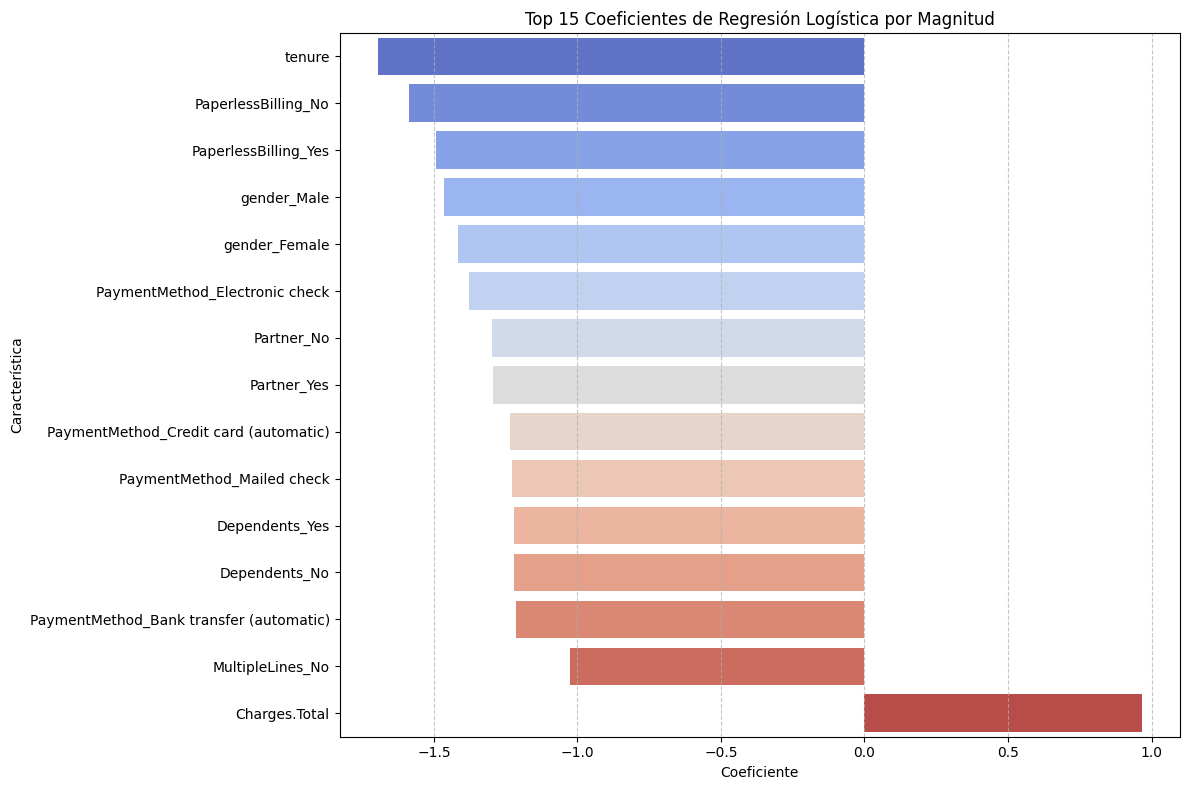


--- Análisis de Importancia de Características de Random Forest ---
Top 10 Características más Importantes (Random Forest):


,Feature,Importance
1,tenure,0.112247
3,Charges.Total,0.112095
2,Charges.Monthly,0.089554
38,Contract_Two year,0.050275
36,Contract_Month-to-month,0.041975
29,TechSupport_Yes,0.039337
39,PaperlessBilling_No,0.038991
20,OnlineSecurity_Yes,0.034650
37,Contract_One year,0.032537
9,Dependents_Yes,0.029944


/tmp/ipykernel_1438/2502860911.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_sorted.head(15), palette='viridis')


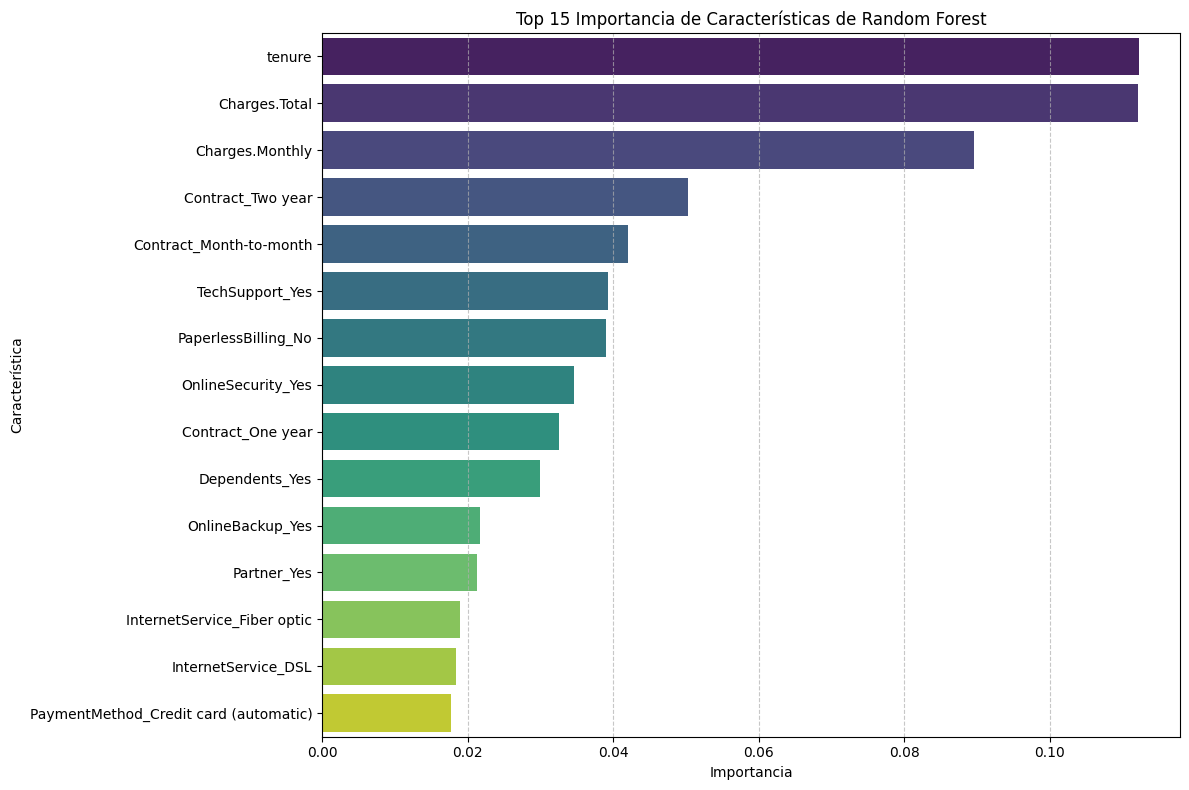

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Regresión Logística: Coeficientes ---
print("\n--- Análisis de Coeficientes de Regresión Logística ---")
# Los coeficientes están en X_train_smote_scaled, necesitamos las columnas de X_train_smote
coefficients = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# Ordenar por valor absoluto del coeficiente para ver la magnitud del impacto
coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients_sorted = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 Coeficientes más Influyentes (Regresión Logística):")
display(coefficients_sorted.head(10))

# Visualizar los coeficientes
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefficients_sorted.head(15), palette='coolwarm')
plt.title('Top 15 Coeficientes de Regresión Logística por Magnitud')
plt.xlabel('Coeficiente')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# --- Random Forest: Importancia de Características ---
print("\n--- Análisis de Importancia de Características de Random Forest ---")
feature_importances = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': rf_model.feature_importances_
})

feature_importances_sorted = feature_importances.sort_values(by='Importance', ascending=False)

print("Top 10 Características más Importantes (Random Forest):")
display(feature_importances_sorted.head(10))

# Visualizar la importancia de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances_sorted.head(15), palette='viridis')
plt.title('Top 15 Importancia de Características de Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Informe Detallado: Análisis y Estrategias de Retención de Clientes

### 1. Resumen Ejecutivo

Este informe presenta los resultados del análisis de la cancelación de clientes (Churn) en el dataset proporcionado. Se entrenaron y evaluaron dos modelos predictivos, Regresión Logística y Random Forest, y se identificaron los factores más influyentes en el comportamiento de churn. El objetivo es ofrecer una comprensión clara de las causas de la cancelación y proponer estrategias accionables para mejorar la retención de clientes.

### 2. Modelos Evaluados y Rendimiento

Se utilizaron dos modelos principales:

*   **Regresión Logística:** Modelo lineal que predice la probabilidad de churn, sensible a la escala de los datos (por lo que se aplicó estandarización).
*   **Random Forest:** Modelo de conjunto basado en árboles de decisión, robusto a la escala de los datos.

**Rendimiento Clave (enfocado en la clase 'Churn' - 1.0):**

| Modelo                 | Accuracy | Precisión (1.0) | Recall (1.0) | F1-score (1.0) |
| :--------------------- | :------- | :-------------- | :----------- | :------------- |
| Regresión Logística    | 0.7851   | 0.60            | 0.58         | 0.59           |
| Random Forest          | 0.7728   | 0.58            | 0.51         | 0.55           |

La **Regresión Logística** mostró un rendimiento ligeramente superior en la identificación de clientes que cancelan (mayor `Recall` y `F1-score` para la clase 1.0), lo que la hace marginalmente más efectiva para detectar clientes en riesgo de churn.

### 3. Principales Factores que Influyen en la Cancelación

Basado en el análisis de coeficientes de Regresión Logística y la importancia de características de Random Forest, los factores más influyentes en la cancelación de clientes son:

*   **Tiempo de Contrato (`tenure`):** **Factor más crítico.** Una `tenure` más larga está fuertemente correlacionada con una **menor probabilidad de churn**. Los clientes nuevos o con poco tiempo son los más vulnerables.
*   **Tipo de Contrato (`Contract_Month-to-month`, `Contract_Two year`):** Los clientes con contratos **mes a mes** (`Contract_Month-to-month`) tienen una **mayor probabilidad de churn**, mientras que los contratos a dos años (`Contract_Two year`) actúan como un fuerte factor protector contra la cancelación.
*   **Cargos (Mensuales y Totales) (`Charges.Monthly`, `Charges.Total`):** **Altos cargos mensuales** (`Charges.Monthly`) se asocian con una **mayor probabilidad de churn**. Aunque `Charges.Total` también es influyente, su correlación es alta con `tenure`, por lo que `Charges.Monthly` puede ser un indicador más directo de insatisfacción con el precio.
*   **Servicio de Internet (`InternetService_Fiber optic`):** Los clientes con servicio de **fibra óptica** (`InternetService_Fiber optic`) muestran una **mayor tendencia a cancelar**, lo que podría indicar problemas de calidad, precio o expectativas no cumplidas con este tipo de servicio.
*   **Método de Pago (`PaymentMethod_Electronic check`):** Los usuarios de **cheques electrónicos** (`PaymentMethod_Electronic check`) tienen una **probabilidad significativamente mayor de churn**.
*   **Servicios Adicionales (Seguridad Online, Soporte Técnico):** La **ausencia de servicios como seguridad online (`OnlineSecurity_No`) y soporte técnico (`TechSupport_No`)** aumenta la probabilidad de cancelación, sugiriendo que estos servicios aportan valor y estabilidad al cliente.
*   **Facturación sin Papel (`PaperlessBilling_Yes` / `PaperlessBilling_No`):** La facturación sin papel (`PaperlessBilling_Yes`) está asociada con una **mayor probabilidad de churn**, lo que podría indicar una menor interacción o lealtad.

### 4. Estrategias de Retención Propuestas

Basándonos en los factores identificados, se proponen las siguientes estrategias de retención:

1.  **Foco en la Incorporación y Primeros Meses:** Implementar programas de bienvenida y seguimiento intensivo para clientes con baja `tenure`. Ofrecer soporte proactivo, verificar la satisfacción y resolver cualquier problema inicial rápidamente para fomentar la lealtad desde el principio.

2.  **Incentivos para Contratos a Largo Plazo:** Promover activamente contratos de 1 o 2 años, ofreciendo descuentos significativos, beneficios exclusivos o mejoras de servicio. Diseñar campañas específicas para migrar clientes de contratos mes a mes a planes más estables.

3.  **Análisis de Precios y Valor para Cargos Altos:** Monitorear a los clientes con cargos mensuales elevados. Realizar encuestas de satisfacción de precios, ofrecer revisiones de planes o proponer paquetes de valor añadido para justificar el costo y evitar que busquen alternativas más baratas.

4.  **Optimización del Servicio de Fibra Óptica:** Investigar la causa del churn en clientes de fibra óptica. Podría ser un problema de rendimiento de red, servicio al cliente específico para fibra, o una fuerte competencia. Implementar mejoras en la calidad del servicio, comunicar el valor diferencial y ofrecer soporte técnico especializado.

5.  **Alternativas y Monitoreo de Métodos de Pago:** Incentivar el uso de métodos de pago automáticos menos asociados al churn, como tarjetas de crédito o transferencias bancarias automáticas, mediante pequeños descuentos o beneficios. Monitorear de cerca a los clientes que usan cheque electrónico y estar alerta a otras señales de riesgo.

6.  **Promoción de Servicios de Valor Añadido:** Destacar y promover los beneficios de la seguridad online y el soporte técnico. Considerar incluirlos en paquetes base o a precios reducidos, especialmente para clientes que no los tienen, para aumentar la percepción de valor y reducir el riesgo de churn.

7.  **Reevaluación de la Facturación sin Papel:** Investigar por qué la facturación sin papel se asocia a un mayor churn. ¿Es una señal de menor compromiso? Considerar formas de mantener la interacción y el valor percibido con estos clientes, quizás a través de comunicaciones personalizadas o incentivos digitales.

### Conclusión

La `tenure` del cliente y el tipo de contrato son los predictores más potentes de la cancelación, complementados por factores como los cargos mensuales, el tipo de servicio de internet y el método de pago. Al enfocarse en estas áreas clave y aplicar las estrategias de retención propuestas, la compañía puede reducir proactivamente la tasa de churn y mejorar la lealtad de sus clientes.